# Spectral Evolution
This script creates an animation of the spectral evolution of supernovae based on models from sncosmo. 
It requires:
- pandas
- matplotlib
- sncosmo
- ffmpeg

These are all pip-installable!

In [1]:
#imports
import pandas as pd
import sncosmo
import matplotlib.pyplot as plt
import matplotlib.animation as animation

In this example, I am going to use SN1993J, however this script should work whatever sncosmo model you use.

In [2]:
#import model
model = sncosmo.Model(source="v19-1993J-corr")

In [3]:
#set up wavelength and epochs to cover - I want integer steps so easiest with range
wave = range(2000, 10001) #remember to add 1 
epochs = range(-5, 231) 

In [4]:
#set up dataframe
spec_df = pd.DataFrame(columns=list(epochs), index=wave)

for epoch in epochs:
    spec_df.loc[:, epoch] = model.flux(epoch, wave)

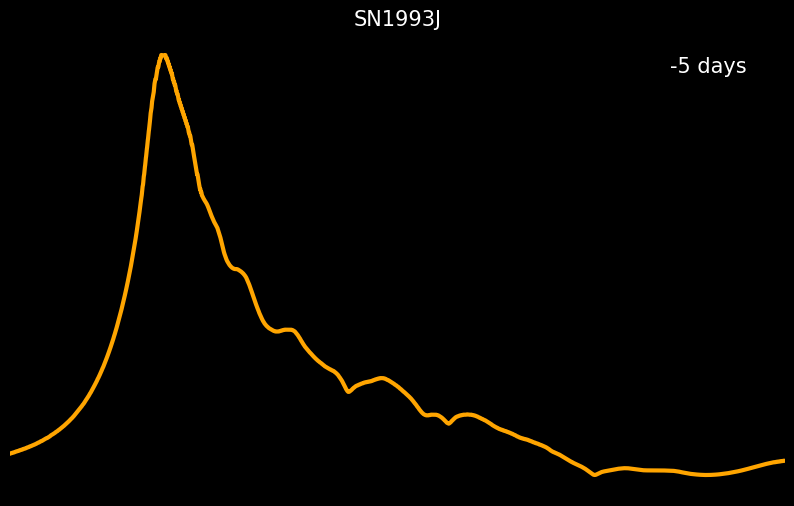

In [5]:
#set up animation
plt.style.use('dark_background') #I think this looks better for slides or videos

fig, ax = plt.subplots(figsize=(10,6))
#initialise animation for first epoch
plt.plot(spec_df.index, spec_df[epochs[0]], c='orange',linewidth=3)

def update(frame):
    
    #clear previous plot
    ax.clear()
    ax.set_title('SN1993J', fontsize=15)
    ax.set_xlim(2000,10000)
    ax.set_axis_off() #keep simple for outreach - don't need to show wavelength or flux for this one
    
    #update the plot for each frame
    line = ax.plot(spec_df.index,spec_df[epochs[frame]],c='orange',linewidth=3)
    #add label for epoch
    ax.text(0.95,0.95, '{} days'.format(spec_df.columns[frame]), verticalalignment='top', horizontalalignment='right', transform=ax.transAxes, fontsize=15)
    
    return(line)

#create animation    
ani = animation.FuncAnimation(fig, update, frames=len(epochs), interval=30)
ani.save("SN1993J-spectralevolution.mp4", writer=animation.FFMpegWriter(fps=5))       